In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
#matrix solver for N = 6

V = 5
V_ = 0

res_ladder = np.array([[3,-1,-1, 0,0,0],
                      [-1, 4,-1,-1,0,0],
                      [-1,-1,4,-1,-1,0],
                      [0,-1,-1,4,-1,-1],
                      [0,0,-1,-1, 4,-1],
                      [0,0, 0,-1,-1, 3]], float)

w = np.array([V, V, 0, 0, V_, V_], float)

N = len(w)

# This section is taken from gauselim from Gezerlis
# Gaussian elimination
for m in range(N):

    # Divide by the diagonal element
    div = res_ladder[m,m]
    res_ladder[m,:] /= div
    w[m] /= div

    # Now subtract from the lower rows
    for i in range(m+1,N):
        mult = res_ladder[i,m]
        res_ladder[i,:] -= mult*res_ladder[m,:]
        w[i] -= mult*w[m]

# Backsubstitution
x = np.empty(N,float)
for m in range(N-1,-1,-1):
    x[m] = w[m]
    for i in range(m+1,N):
        x[m] -= res_ladder[m,i]*x[i]

print(x)

[3.7254902  3.43137255 2.74509804 2.25490196 1.56862745 1.2745098 ]


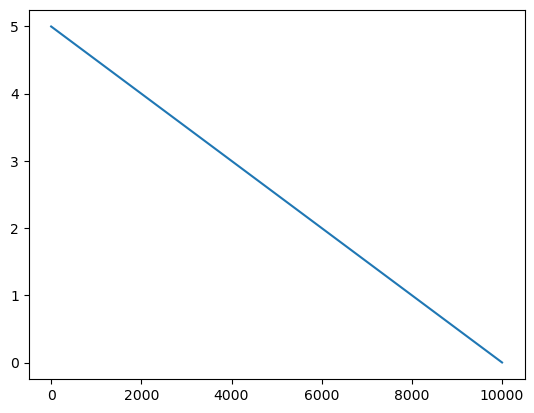

In [31]:
#matrix_solver for N = 10,000

def banded(Aa,va,up,down):

    # Copy the inputs and determine the size of the system
    A = np.copy(Aa)
    v = np.copy(va)
    N = len(v)

    # Gaussian elimination
    for m in range(N):

        # Normalization factor
        div = A[up,m]

        # Update the vector first
        v[m] /= div
        for k in range(1,down+1):
            if m+k<N:
                v[m+k] -= A[up+k,m]*v[m]

        # Now normalize the pivot row of A and subtract from lower ones
        for i in range(up):
            j = m + up - i
            if j<N:
                A[i,j] /= div
                for k in range(1,down+1):
                    A[i+k,j] -= A[up+k,m]*A[i,j]

    # Backsubstitution
    for m in range(N-2,-1,-1):
        for i in range(up):
            j = m + up - i
            if j<N:
                v[m] -= A[i,j]*v[j]

    return v

A = np.zeros((10000,10000))

for m in range(10000):
    A[m,m] = 4
    A[m-1,m] = -1
    A[m-2,m] = -1
    A[m, m-1] = -1
    A[m, m-2] = -1

A[9999,0] = 0
A[9998,0] = 0
A[9999,1] = 0
A[0,9999] = 0
A[0,9998] = 0
A[1,9999] = 0
A[0,0] = 3
A[9999,9999] = 3

B = np.zeros((5,10000))

for m in range(10000):
    B[0,m] = -1
    B[1,m] = -1
    B[2,m] = 4
    B[3,m] = -1
    B[4,m] = -1
B[2,0]=3
B[2,9999]=3

V = 5
V_ = 0

v = np.zeros(10000)
v[0]= V
v[1]= V
v[9998] = V_
v[9999] = V_


z = banded(B, v, 2, 2)


fig, ax1 = plt.subplots()

ax1.plot(np.linspace(0,10000, num=10000), banded(B,v,2,2))

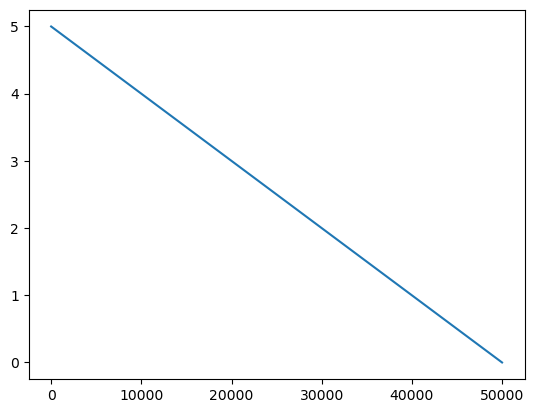

In [28]:
# varying n
B_a = np.zeros((5,50000))

for m in range(50000):
    B_a[0,m] = -1
    B_a[1,m] = -1
    B_a[2,m] = 4
    B_a[3,m] = -1
    B_a[4,m] = -1
B_a[2,0]=3
B_a[2,49999]=3

v0 = np.zeros(50000)
v0[0]= V
v0[1]= V
v0[49998] = V_
v0[49999] = V_



a0 = banded(B_a, v0, 2, 2)

fig, ax1 = plt.subplots()

ax1.plot(np.linspace(0,50000, num=50000), a0)


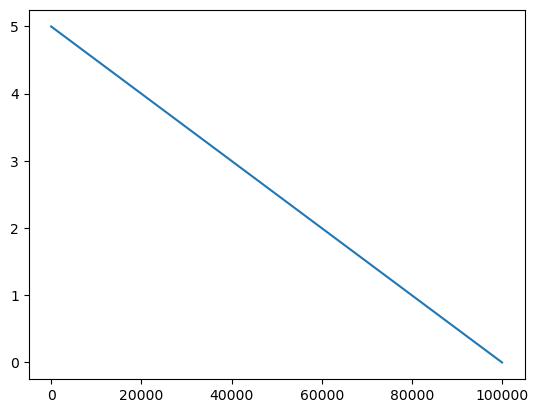

In [30]:
# varying n
B_b = np.zeros((5,100000))

for m in range(100000):
    B_b[0,m] = -1
    B_b[1,m] = -1
    B_b[2,m] = 4
    B_b[3,m] = -1
    B_b[4,m] = -1
B_b[2,0]=3
B_b[2,99999]=3

v1 = np.zeros(100000)
v1[0]= V
v1[1]= V
v1[99998] = V_
v1[99999] = V_



a1 = banded(B_b, v1, 2, 2)

fig, ax1 = plt.subplots()

ax1.plot(np.linspace(0,100000, num=100000), a1)